# Chunk Labeling and Class Imbalance - Aarabhi Kuchi

This notebook turns the contract chunks from `Subword_Tokenization_Chunking.ipynb` (Dzifa) into labeled training data for the models. It:
1. loads the 512-token RoBERTa chunks (with their character positions) and the lawyer-highlighted answers,
2. labels each chunk with the clause categories it contains (41 yes/no labels per chunk),
3. checks the labels are correct,
4. explores class imbalance per clause category,
5. saves the labeled chunks for Task #5 (label matrix), Task #6 (TF-IDF) and the baseline model.

In [1]:
import json, re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load the data
I load the official CUAD split (same files as every other notebook) and the chunks saved by the chunking notebook (`data/train_chunks.parquet` and `data/test_chunks.parquet`). If the chunk files haven't been saved yet, the cell below rebuilds them with the exact same settings as the chunking notebook (`roberta-base`, 512 tokens, 128-token overlap).

In [2]:
with open('../data/train_separate_questions.json', 'r') as file:
    train_json = json.load(file)
with open('../data/test.json', 'r') as file:
    test_json = json.load(file)

def get_contracts(cuad_json):
    contracts = []
    for contract in cuad_json['data']:
        for paragraph in contract['paragraphs']:
            contracts.append({"title": contract['title'], "context": paragraph['context']})
    return pd.DataFrame(contracts)

train_contracts = get_contracts(train_json)
test_contracts = get_contracts(test_json)
print("Contracts:", len(train_contracts), "train /", len(test_contracts), "test")   # expect 408 / 102

Contracts: 408 train / 102 test


In [3]:
TRAIN_CHUNKS_PATH = '../data/train_chunks.parquet'
TEST_CHUNKS_PATH = '../data/test_chunks.parquet'

if os.path.exists(TRAIN_CHUNKS_PATH) and os.path.exists(TEST_CHUNKS_PATH):
    train_chunks = pd.read_parquet(TRAIN_CHUNKS_PATH)
    test_chunks = pd.read_parquet(TEST_CHUNKS_PATH)
    print("Loaded saved chunks from the chunking notebook.")
else:
    # Fallback: rebuild chunks with the same settings as Subword_Tokenization_Chunking.ipynb
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained("roberta-base", use_fast=True)

    def sub_tokenizer(title, context):
        encoded = tokenizer(context, max_length=512, stride=128, truncation=True,
                            return_overflowing_tokens=True, return_offsets_mapping=True)
        chunk_info = []
        for chunk_id, offsets in enumerate(encoded["offset_mapping"]):
            valid = [(s, e) for s, e in offsets if e > s]
            chunk_info.append({"title": title, "chunk_id": chunk_id,
                               "char_start": valid[0][0], "char_end": valid[-1][1],
                               "chunk_text": context[valid[0][0]:valid[-1][1]]})
        return chunk_info

    def tokenize_contracts(contracts):
        all_chunks = []
        for _, contract in contracts.iterrows():
            all_chunks.extend(sub_tokenizer(contract["title"], contract["context"]))
        return pd.DataFrame(all_chunks)

    train_chunks = tokenize_contracts(train_contracts)
    test_chunks = tokenize_contracts(test_contracts)
    print("Rebuilt chunks with roberta-base.")

print("Chunks:", len(train_chunks), "train /", len(test_chunks), "test")   # expect 14,181 / 2,898
train_chunks.head(3)

Loaded saved chunks from the chunking notebook.
Chunks: 14181 train / 2898 test


,title,chunk_id,char_start,char_end,chunk_text
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,0,0,1813,EXHIBIT 10.6\n\n ...
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,1,1271,2688,produced and supplied as needed pursuant to th...
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,2,2409,3434,"Market, and Distributor hereby accepts..."


## 2. Clause categories and answer positions
Each question names its clause category inside quotes (e.g. `"Governing Law"`). For every highlighted answer, I record its category and its character range in the contract: `answer_start` comes from CUAD, and `answer_end = answer_start + len(answer text)`.

In [4]:
def get_category(question):
    match = re.search(r'"([^"]+)"', question)
    if match:
        return match.group(1)
    return None

CATEGORIES = sorted({get_category(qa['question'])
                     for contract in train_json['data']
                     for paragraph in contract['paragraphs']
                     for qa in paragraph['qas']})
print(len(CATEGORIES), "categories")   # expect 41

41 categories


In [5]:
def get_answer_spans(cuad_json):
    rows = []
    for contract in cuad_json['data']:
        for paragraph in contract['paragraphs']:
            for qa in paragraph['qas']:
                for answer in qa['answers']:
                    start = answer['answer_start']
                    rows.append({"title": contract['title'],
                                 "category": get_category(qa['question']),
                                 "answer_start": start,
                                 "answer_end": start + len(answer['text']),
                                 "answer_text": answer['text']})
    return pd.DataFrame(rows)

train_spans = get_answer_spans(train_json)
test_spans = get_answer_spans(test_json)
print("Answer spans:", len(train_spans), "train /", len(test_spans), "test")
train_spans.head(3)

Answer spans: 11180 train / 2643 test


,title,category,answer_start,answer_end,answer_text
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,44,65,DISTRIBUTOR AGREEMENT
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,244,255,Distributor
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,49574,49606,Electric City of Illinois L.L.C.


## 3. Label each chunk
A chunk gets a **1** for a category if **any** highlighted answer of that category overlaps the chunk's character range, and **0** otherwise. Two ranges overlap when `answer_start < char_end` and `answer_end > char_start`.

Because chunks overlap by 128 tokens, one answer can make two neighboring chunks positive, which is expected. Long answers can also span several chunks.

In [6]:
def label_chunks(chunks_df, spans_df, categories):
    labeled = chunks_df.reset_index(drop=True).copy()
    labels = np.zeros((len(labeled), len(categories)), dtype=np.int8)
    cat_index = {cat: i for i, cat in enumerate(categories)}

    # Work one contract at a time so we only compare a contract's answers with its own chunks
    chunk_rows = labeled.groupby("title").indices
    for title, spans in spans_df.groupby("title"):
        if title not in chunk_rows:
            continue
        rows = chunk_rows[title]
        starts = labeled.loc[rows, "char_start"].to_numpy()
        ends = labeled.loc[rows, "char_end"].to_numpy()
        for _, span in spans.iterrows():
            overlaps = (starts < span["answer_end"]) & (ends > span["answer_start"])
            labels[rows[overlaps], cat_index[span["category"]]] = 1

    label_df = pd.DataFrame(labels, columns=categories)
    return pd.concat([labeled, label_df], axis=1)

train_labeled = label_chunks(train_chunks, train_spans, CATEGORIES)
test_labeled = label_chunks(test_chunks, test_spans, CATEGORIES)
print("Train:", train_labeled.shape, " Test:", test_labeled.shape)

Train: (14181, 46)  Test: (2898, 46)


## 4. Checking the labels
Four checks:
1. **Every answer is covered:** each highlighted answer overlaps at least one chunk labeled with its category.
2. **Answers fit inside chunks:** how many answers sit fully inside a single chunk (very long answers can be split across chunks).
3. **Spot check:** for a few answers, print the labeled chunk and confirm the answer text is really in it.
4. **Validation checks:** the labels are only 0/1 with no missing values, every answer has a real category (no `None`), every contract has chunks, each `chunk_text` matches the contract text at its `char_start`/`char_end`, and no contract is in both train and test.

A chunk that doesn't contain any of the 41 clauses stays all 0s. That is the "no label" case, so it doesn't need a separate `None` value.

In [7]:
def coverage_check(labeled, spans):
    covered, fully_inside = 0, 0
    for _, span in spans.iterrows():
        rows = labeled[labeled["title"] == span["title"]]
        overlap = rows[(rows["char_start"] < span["answer_end"]) & (rows["char_end"] > span["answer_start"])]
        if (overlap[span["category"]] == 1).any():
            covered += 1
        inside = rows[(rows["char_start"] <= span["answer_start"]) & (rows["char_end"] >= span["answer_end"])]
        if len(inside) > 0:
            fully_inside += 1
    print(f"Answers covered by a positive chunk: {covered:,} / {len(spans):,}")
    print(f"Answers fully inside one chunk:      {fully_inside:,} / {len(spans):,} "
          f"({fully_inside / len(spans) * 100:.1f}%)")

print("TRAIN"); coverage_check(train_labeled, train_spans)
print("\nTEST");  coverage_check(test_labeled, test_spans)

TRAIN


Answers covered by a positive chunk: 11,180 / 11,180
Answers fully inside one chunk:      10,932 / 11,180 (97.8%)

TEST
Answers covered by a positive chunk: 2,643 / 2,643
Answers fully inside one chunk:      2,585 / 2,643 (97.8%)


In [8]:
# Spot check: 3 random answers -> find a chunk labeled with that category and confirm the answer text is inside
for _, span in train_spans.sample(3, random_state=42).iterrows():
    rows = train_labeled[(train_labeled["title"] == span["title"]) &
                         (train_labeled["char_start"] <= span["answer_start"]) &
                         (train_labeled["char_end"] >= span["answer_end"])]
    print("Category:", span["category"])
    print("Answer:  ", span["answer_text"][:150])
    if len(rows) > 0:
        chunk = rows.iloc[0]
        print("Chunk", chunk["chunk_id"], "label =", chunk[span["category"]],
              "| answer text found in chunk:", span["answer_text"] in chunk["chunk_text"])
    else:
        print("Answer is longer than one chunk (split across chunks).")
    print("-" * 80)

Category: Insurance
Answer:   MD Anderson has and will maintain in force during the term of this Agreement adequate insurance or financial resources to cover its obligations pursua
Chunk 31 label = 1 | answer text found in chunk: True
--------------------------------------------------------------------------------
Category: Most Favored Nation
Answer:   In addition, in the event that iVillage desires to form a sponsorship relationship with an automobile rental company during the term of this Agreement
Chunk 6 label = 1 | answer text found in chunk: True
--------------------------------------------------------------------------------
Category: Ip Ownership Assignment
Answer:   Assignor does hereby irrevocably sell, convey, grant, set over, assign and transfer to Assignee, without reservation of any rights, title or interest,
Answer is longer than one chunk (split across chunks).
--------------------------------------------------------------------------------


In [9]:
def validate_labels(labeled, chunks, spans, contracts, categories, name):
    # 1. Same number of rows as the chunks we started with
    assert len(labeled) == len(chunks), f"{name}: row count changed"
    # 2. Exactly 41 label columns, only 0s and 1s, no missing values
    assert len(categories) == 41, f"expected 41 categories, got {len(categories)}"
    assert labeled[categories].isna().sum().sum() == 0, f"{name}: missing label values"
    assert labeled[categories].isin([0, 1]).all().all(), f"{name}: labels other than 0/1"
    # 3. Every answer has a real category (no None from get_category)
    assert spans["category"].notna().all(), f"{name}: an answer has no category"
    assert spans["category"].isin(categories).all(), f"{name}: unknown category"
    # 4. Every contract has chunks, and chunk positions are valid
    assert set(contracts["title"]) == set(labeled["title"]), f"{name}: a contract has no chunks"
    assert (labeled["char_start"] < labeled["char_end"]).all(), f"{name}: empty or reversed chunk"
    # 5. chunk_text really matches the contract text at those positions
    text_by_title = dict(zip(contracts["title"], contracts["context"]))
    matches = labeled.apply(lambda r: text_by_title[r["title"]][r["char_start"]:r["char_end"]] == r["chunk_text"], axis=1)
    assert matches.all(), f"{name}: {(~matches).sum()} chunks don't match the contract text"
    # 6. Every answer position is inside its contract
    lengths = spans["title"].map(lambda t: len(text_by_title[t]))
    assert (spans["answer_end"] <= lengths).all(), f"{name}: answer goes past end of contract"
    print(f"{name}: all checks passed ({len(labeled):,} chunks, {len(spans):,} answers)")

validate_labels(train_labeled, train_chunks, train_spans, train_contracts, CATEGORIES, "TRAIN")
validate_labels(test_labeled, test_chunks, test_spans, test_contracts, CATEGORIES, "TEST")
assert not set(train_contracts["title"]) & set(test_contracts["title"]), "a contract is in both train and test"
print("No contract appears in both train and test.")

TRAIN: all checks passed (14,181 chunks, 11,180 answers)
TEST: all checks passed (2,898 chunks, 2,643 answers)
No contract appears in both train and test.


All answers should be covered by a positive chunk (this is how the labels are built, so anything less would signal a bug). Most answers fit inside a single chunk; the ones that don't are long clauses that span more than 512 tokens, which still get labeled in every chunk they touch. In the spot check, each answer's text appears inside its labeled chunk, which confirms the character positions line up between Dzifa's chunks and the CUAD answers. The validation cell prints "all checks passed" for both train and test, so the label matrix is clean and ready to use.

## 5. Class imbalance per clause category
Two views of imbalance:
- **Contracts per category:** how many contracts contain each clause at least once.
- **Chunks per category:** how many chunks are labeled positive. This is what the model is actually trained on.

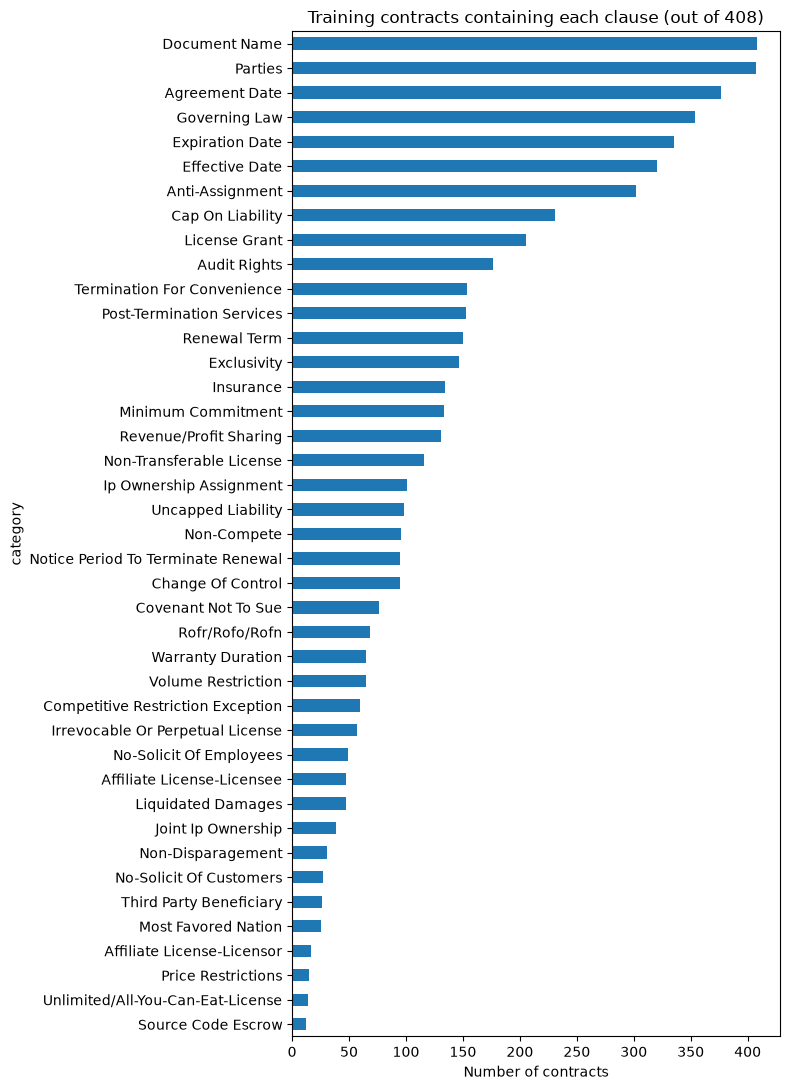

Rarest 5:
 category
Source Code Escrow                   12
Unlimited/All-You-Can-Eat-License    14
Price Restrictions                   15
Affiliate License-Licensor           17
Most Favored Nation                  25

Most common 5:
 category
Expiration Date    335
Governing Law      354
Agreement Date     377
Parties            407
Document Name      408


In [10]:
def get_presence(cuad_json):
    rows = []
    for contract in cuad_json['data']:
        for paragraph in contract['paragraphs']:
            for qa in paragraph['qas']:
                rows.append({"title": contract['title'],
                             "category": get_category(qa['question']),
                             "present": not qa['is_impossible']})
    return pd.DataFrame(rows)

presence = get_presence(train_json)
contracts_per_cat = (presence[presence["present"]]
                     .groupby("category")["title"].nunique()     # unique contracts, not rows
                     .reindex(CATEGORIES, fill_value=0)
                     .sort_values())

plt.figure(figsize=(8, 11))
contracts_per_cat.plot(kind="barh")
plt.title(f"Training contracts containing each clause (out of {len(train_contracts)})")
plt.xlabel("Number of contracts")
plt.tight_layout()
plt.show()

print("Rarest 5:\n", contracts_per_cat.head(5).to_string())
print("\nMost common 5:\n", contracts_per_cat.tail(5).to_string())

In [11]:
chunks_per_cat = train_labeled[CATEGORIES].sum().sort_values()
pct_chunks = (chunks_per_cat / len(train_labeled) * 100).round(2)

imbalance = pd.DataFrame({"contracts": contracts_per_cat.reindex(chunks_per_cat.index),
                          "positive_chunks": chunks_per_cat,
                          "% of chunks": pct_chunks})

# Highlight categories in under 1% of chunks (the rarest ones)
imbalance.style.apply(lambda row: ["background-color: #ffe0b2" if row["% of chunks"] < 1 else "" for _ in row], axis=1)

,contracts,positive_chunks,% of chunks
Unlimited/All-You-Can-Eat-License,14,31,0.220000
Price Restrictions,15,34,0.240000
Third Party Beneficiary,26,42,0.300000
Source Code Escrow,12,47,0.330000
Most Favored Nation,25,51,0.360000
No-Solicit Of Customers,27,53,0.370000
Affiliate License-Licensor,17,63,0.440000
Non-Disparagement,31,64,0.450000
No-Solicit Of Employees,49,86,0.610000
Joint Ip Ownership,39,99,0.700000


In [12]:
no_label = (train_labeled[CATEGORIES].sum(axis=1) == 0).mean() * 100
print(f"Training chunks with NO clause label at all: {no_label:.1f}%")
print(f"Average labels per chunk: {train_labeled[CATEGORIES].sum(axis=1).mean():.2f}")
print(f"Categories in under 1% of chunks: {(pct_chunks < 1).sum()} / {len(CATEGORIES)}")

Training chunks with NO clause label at all: 58.1%
Average labels per chunk: 0.76
Categories in under 1% of chunks: 13 / 41


### What this shows

- **contracts**: how many contracts have this clause at least once (out of 408).
- **positive_chunks**: how many chunks are labeled 1 for this category, meaning part of a lawyer-highlighted answer falls inside that chunk.
- **% of chunks**: positive_chunks ÷ 14,181 total train chunks. This is how often the model will see a "yes" example for this category.
- **Highlighted rows**: categories in under 1% of chunks. These are the hardest to learn, so we use per-category precision/recall/F1 and `class_weight="balanced"` instead of accuracy.

## 6. Save the labeled chunks
These files are the handoff to Task #5, Task #6 and the baseline model. They are saved in `data/`, next to the chunk files from the chunking notebook. The label column order is also saved in `categories.json` so every team uses the same order.

In [13]:
train_labeled.to_parquet('../data/train_chunks_labeled.parquet', index=False)
test_labeled.to_parquet('../data/test_chunks_labeled.parquet', index=False)
with open('../data/categories.json', 'w') as f:
    json.dump(CATEGORIES, f, indent=1)

# Re-load to confirm the files are readable and match
check = pd.read_parquet('../data/train_chunks_labeled.parquet')
print("Saved:", check.shape, "| columns:", list(check.columns[:5]), "+", len(CATEGORIES), "label columns")

Saved: (14181, 46) | columns: ['title', 'chunk_id', 'char_start', 'char_end', 'chunk_text'] + 41 label columns


## 7. Summary

Each chunk is labeled 1 for a category if any lawyer-highlighted answer for that category overlaps it, and 0 otherwise. This turns CUAD's answer spans into a 41-column label matrix that both the TF-IDF baseline and later models can train on.

**Output files** (in `data/`): `train_chunks_labeled.parquet`, `test_chunks_labeled.parquet`, and `categories.json` (the 41 category names, in label-column order). Columns are `title`, `chunk_id`, `char_start`, `char_end`, `chunk_text`, then one 0/1 column per category.

### Key findings

- **Data size:** 408 train / 102 test contracts → 14,181 / 2,898 chunks, 41 categories, 11,180 / 2,643 answer spans.
- **Coverage:** 100% of answer spans land in at least one chunk, and 97.8% fit fully inside a single chunk.
- **Most chunks are empty:** 58.1% of chunks have no label at all, and the average is 0.76 labels per chunk.
- **Severe imbalance:** 13 of 41 categories appear in under 1% of chunks.
- **Rarest categories (contracts):** Source Code Escrow (12), Unlimited/All-You-Can-Eat-License (14), Price Restrictions (15), Affiliate License-Licensor (17), Most Favored Nation (25).
- **Most common categories (contracts):** Document Name (408), Parties (407), Agreement Date (377), Governing Law (354), Expiration Date (335).
- **Most positive chunks:** License Grant, at 4.94% of chunks. Even the most common category is a small minority at chunk level.

### Limitations

- A chunk counts as positive even if only part of a clause falls inside it.
- Rare categories have very few test examples, so their scores will vary a lot.